# Forecasting Time Series Bulanan - Gempa M>=5 (Auto Select Model)
Notebook ini membandingkan beberapa model bulanan untuk memprediksi jumlah gempa **M>=5** per bulan,
memilih model terbaik berdasarkan metrik validasi, lalu membuat prediksi 12 bulan ke depan.

**Perbedaan dengan notebook auto-select asli:** notebook ini hanya menghitung gempa dengan magnitude >= 5.0,
sesuai dengan notebook model lainnya (model_a, model_b, model_compare_sarima_sgboost, model_compare_tcn).

## Alur
1. Load data gempa (katalog_gempa_v2.tsv)
2. Filter gempa dengan magnitude >= 5.0
3. Bentuk deret waktu bulanan
4. Split train/test (12 bulan terakhir sebagai test)
5. Latih dan evaluasi model kandidat (Seasonal Naive, Holt-Winters, SARIMA, XGBoost, LSTM)
6. Pilih model terbaik dan forecast 12 bulan ke depan
7. Simpan artifact (metrics, prediksi test, train/test split, dan forecast)

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Optional: XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

# Optional: TensorFlow/Keras untuk LSTM
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

if TF_AVAILABLE:
    tf.random.set_seed(42)

print(f'XGBoost available: {XGB_AVAILABLE}')
print(f'TensorFlow available: {TF_AVAILABLE}')


XGBoost available: True
TensorFlow available: True


In [2]:
# Konfigurasi utama
DATA_PATH = Path('data_gempa_kaggle/katalog_gempa_v2.tsv')
ARTIFACT_DIR = Path('artifacts/model_monthly_auto_select_m5')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MAG_THRESHOLD = 5.0
TARGET_COL = 'count_m5'
TEST_HORIZON = 12
SEASONAL_PERIOD = 12

print('Data path:', DATA_PATH)
print('Artifact dir:', ARTIFACT_DIR.resolve())
print('MAG_THRESHOLD:', MAG_THRESHOLD)

Data path: data_gempa_kaggle\katalog_gempa_v2.tsv
Artifact dir: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_monthly_auto_select_m5
MAG_THRESHOLD: 5.0


In [3]:
# Load data dan filter berdasarkan magnitude
df = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
df = df.dropna(subset=['datetime', 'magnitude']).copy()
df['datetime'] = df['datetime'].dt.tz_convert(None)

print('Total rows after cleaning:', len(df))
print('Min datetime:', df['datetime'].min())
print('Max datetime:', df['datetime'].max())

# Filter hanya gempa M >= 5.0
df_m5 = df[df['magnitude'] >= MAG_THRESHOLD].copy()
print(f'\nRows with magnitude >= {MAG_THRESHOLD}:', len(df_m5))

# Agregasi bulanan: hitung jumlah gempa M>=5 per bulan
ts = df_m5.set_index('datetime').resample('MS').size().astype(float)
ts = ts.asfreq('MS').fillna(0.0)  # bulan tanpa gempa M>=5 => 0

# Drop bulan terakhir jika parsial
last_ts = df['datetime'].max()
last_month_end = last_ts.to_period('M').end_time
if last_ts < last_month_end and len(ts) > 0:
    ts = ts.iloc[:-1]
    print('Dropped partial last month.')

if len(ts) < (TEST_HORIZON + 24):
    raise ValueError('Data terlalu pendek. Butuh minimal sekitar 36 observasi bulanan.')

print('\nTarget:', TARGET_COL)
print('Rentang data:', ts.index.min().date(), 'sampai', ts.index.max().date())
print('Jumlah titik bulanan:', len(ts))
ts.tail()

Total rows after cleaning: 131131
Min datetime: 2008-11-01 00:31:25.143741
Max datetime: 2025-10-01 12:30:19.302639

Rows with magnitude >= 5.0: 4809
Dropped partial last month.

Target: count_m5
Rentang data: 2008-11-01 sampai 2025-08-01
Jumlah titik bulanan: 202


datetime
2025-04-01     5.0
2025-05-01     7.0
2025-06-01     1.0
2025-07-01    10.0
2025-08-01    11.0
Freq: MS, dtype: float64

In [4]:
# Split train/test
train = ts.iloc[:-TEST_HORIZON]
test = ts.iloc[-TEST_HORIZON:]

N_LAGS = 12

print(f'Train: {len(train)} bulan ({train.index.min().date()} s/d {train.index.max().date()})')
print(f'Test:  {len(test)} bulan ({test.index.min().date()} s/d {test.index.max().date()})')

def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.abs(y_true) + np.abs(y_pred)
    mask = den != 0
    if not np.any(mask):
        return np.nan
    return np.mean(2.0 * np.abs(y_true[mask] - y_pred[mask]) / den[mask]) * 100.0

def metric_frame(name, y_true, y_pred):
    return {
        'model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mape(y_true, y_pred),
        'sMAPE(%)': smape(y_true, y_pred)
    }

def make_supervised(values, n_lags):
    X, y = [], []
    for i in range(n_lags, len(values)):
        X.append(values[i - n_lags:i])
        y.append(values[i])
    return np.array(X), np.array(y)

def recursive_forecast_sklearn(model, history_values, steps, n_lags):
    history = list(history_values)
    preds = []
    for _ in range(steps):
        x_input = np.array(history[-n_lags:]).reshape(1, -1)
        pred = float(model.predict(x_input)[0])
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

def recursive_forecast_lstm(model, history_values, steps, n_lags):
    history = list(history_values)
    preds = []
    for _ in range(steps):
        x_input = np.array(history[-n_lags:]).reshape(1, n_lags, 1)
        pred = float(model.predict(x_input, verbose=0).ravel()[0])
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

def post_process_forecast(values):
    values = np.array(values, dtype=float)
    values = np.clip(values, 0, None)  # jumlah gempa tidak bisa negatif
    return values

results = []
predictions = {}

Train: 190 bulan (2008-11-01 s/d 2024-08-01)
Test:  12 bulan (2024-09-01 s/d 2025-08-01)


In [5]:
# Model 1: Seasonal Naive
last_year = train.iloc[-SEASONAL_PERIOD:].values
pred_naive = np.resize(last_year, TEST_HORIZON)
pred_naive = post_process_forecast(pred_naive)
pred_naive = pd.Series(pred_naive, index=test.index)
predictions['SeasonalNaive'] = pred_naive
results.append(metric_frame('SeasonalNaive', test, pred_naive))

# Model 2: Holt-Winters Exponential Smoothing
hw = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=SEASONAL_PERIOD
).fit(optimized=True)
pred_hw = post_process_forecast(hw.forecast(TEST_HORIZON).values)
pred_hw = pd.Series(pred_hw, index=test.index)
predictions['HoltWintersAdd'] = pred_hw
results.append(metric_frame('HoltWintersAdd', test, pred_hw))

# Model 3: SARIMA grid kecil, pilih berdasarkan AIC di train
best_aic = np.inf
best_order = None
best_seasonal = None
best_sarima_fit = None

for order in [(1,0,1), (1,1,1), (2,1,1), (2,1,2)]:
    for seas in [(0,1,1,SEASONAL_PERIOD), (1,1,1,SEASONAL_PERIOD), (1,0,1,SEASONAL_PERIOD)]:
        try:
            fit = SARIMAX(
                train,
                order=order,
                seasonal_order=seas,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = order
                best_seasonal = seas
                best_sarima_fit = fit
        except Exception:
            continue

if best_sarima_fit is not None:
    pred_sarima = post_process_forecast(best_sarima_fit.forecast(TEST_HORIZON).values)
    pred_sarima = pd.Series(pred_sarima, index=test.index)
    predictions['SARIMA'] = pred_sarima
    results.append(metric_frame('SARIMA', test, pred_sarima))
    print('Best SARIMA:', best_order, best_seasonal, 'AIC=', round(best_aic, 2))
else:
    print('SARIMA gagal dilatih pada kombinasi yang dicoba.')

# Model 4: XGBoost Regressor (lag features)
xgb_model = None
if XGB_AVAILABLE and len(train) > N_LAGS:
    X_train_xgb, y_train_xgb = make_supervised(train.values, N_LAGS)
    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42
    )
    xgb_model.fit(X_train_xgb, y_train_xgb)
    pred_xgb = recursive_forecast_sklearn(xgb_model, train.values, TEST_HORIZON, N_LAGS)
    pred_xgb = post_process_forecast(pred_xgb)
    pred_xgb = pd.Series(pred_xgb, index=test.index)
    predictions['XGBoost'] = pred_xgb
    results.append(metric_frame('XGBoost', test, pred_xgb))
else:
    print('XGBoost dilewati (package tidak tersedia atau data train terlalu pendek).')

# Model 5: LSTM (lag sequence)
lstm_model = None
lstm_scaler = None
if TF_AVAILABLE and len(train) > N_LAGS + 6:
    lstm_scaler = MinMaxScaler()
    train_scaled = lstm_scaler.fit_transform(train.values.reshape(-1, 1)).ravel()
    X_train_lstm, y_train_lstm = make_supervised(train_scaled, N_LAGS)
    X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)

    lstm_model = Sequential([
        LSTM(32, input_shape=(N_LAGS, 1)),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    lstm_model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=120,
        batch_size=8,
        verbose=0,
        callbacks=[es]
    )

    pred_lstm_scaled = recursive_forecast_lstm(
        lstm_model, train_scaled, TEST_HORIZON, N_LAGS
    )
    pred_lstm = lstm_scaler.inverse_transform(pred_lstm_scaled.reshape(-1, 1)).ravel()
    pred_lstm = post_process_forecast(pred_lstm)
    pred_lstm = pd.Series(pred_lstm, index=test.index)
    predictions['LSTM'] = pred_lstm
    results.append(metric_frame('LSTM', test, pred_lstm))
else:
    print('LSTM dilewati (TensorFlow tidak tersedia atau data train terlalu pendek).')

Best SARIMA: (2, 1, 2) (1, 1, 1, 12) AIC= 1355.2





In [6]:
# Simpan masing-masing model kandidat (format menyesuaikan tipe model)
import json
import joblib

MODEL_DIR = ARTIFACT_DIR / 'saved_models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

saved_model_files = []

# Seasonal Naive: simpan payload parameter + pattern musiman terakhir
seasonal_naive_payload = {
    'model_type': 'SeasonalNaive',
    'seasonal_period': SEASONAL_PERIOD,
    'last_year_pattern': train.iloc[-SEASONAL_PERIOD:].tolist(),
    'mag_threshold': MAG_THRESHOLD,
    'target': TARGET_COL
}
joblib.dump(seasonal_naive_payload, MODEL_DIR / 'seasonal_naive.pkl')
saved_model_files.append('seasonal_naive.pkl')

# Holt-Winters (statsmodels) -> pkl
joblib.dump(hw, MODEL_DIR / 'holtwinters_add.pkl')
saved_model_files.append('holtwinters_add.pkl')

# SARIMA (statsmodels) -> pkl jika tersedia
if best_sarima_fit is not None:
    joblib.dump(best_sarima_fit, MODEL_DIR / 'sarima.pkl')
    saved_model_files.append('sarima.pkl')

# XGBoost -> pkl jika tersedia
if xgb_model is not None:
    joblib.dump(xgb_model, MODEL_DIR / 'xgboost.pkl')
    saved_model_files.append('xgboost.pkl')

# LSTM keras: simpan model native .keras + scaler .pkl
if lstm_model is not None:
    lstm_model.save(MODEL_DIR / 'lstm.keras')
    saved_model_files.append('lstm.keras')

if lstm_scaler is not None:
    joblib.dump(lstm_scaler, MODEL_DIR / 'lstm_scaler.pkl')
    saved_model_files.append('lstm_scaler.pkl')

with open(MODEL_DIR / 'model_manifest.json', 'w', encoding='utf-8') as f:
    json.dump({'saved_models': saved_model_files}, f, indent=2)

print('Model tersimpan di:', MODEL_DIR.resolve())
print('Saved model files:')
for fname in saved_model_files:
    print('-', fname)

Model tersimpan di: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_monthly_auto_select_m5\saved_models
Saved model files:
- seasonal_naive.pkl
- holtwinters_add.pkl
- sarima.pkl
- xgboost.pkl
- lstm.keras
- lstm_scaler.pkl


In [7]:
# Evaluasi dan pilih model terbaik
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
best_model_name = results_df.loc[0, 'model']

display(results_df)
print(f'Model terbaik (berdasarkan MAE): {best_model_name}')

,model,MAE,RMSE,MAPE,sMAPE(%)
0,SARIMA,4.666275,5.547448,114.644853,53.574306
1,HoltWintersAdd,5.019537,6.202823,125.661104,55.605332
2,XGBoost,6.449505,7.653711,178.163164,61.270833
3,LSTM,6.687601,7.743229,206.327981,64.208946
4,SeasonalNaive,7.666667,10.816654,191.069209,64.033497


Model terbaik (berdasarkan MAE): SARIMA


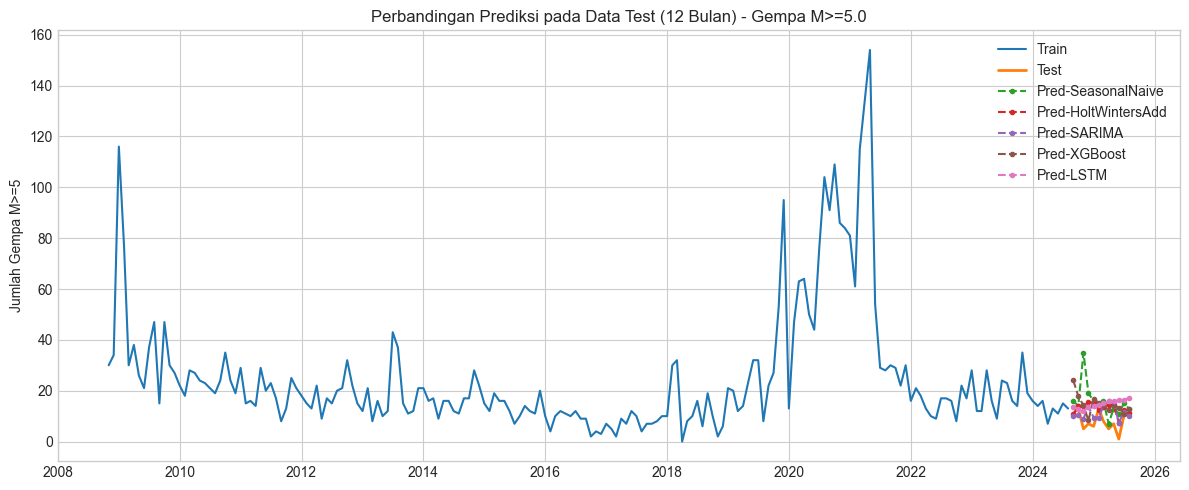

,actual,pred_holtwinters
datetime,,
2024-09-01,11.0,10.699132
2024-10-01,13.0,13.953061
2024-11-01,5.0,13.840635
2024-12-01,7.0,15.660783
2025-01-01,6.0,15.157357
2025-02-01,13.0,12.217775
2025-03-01,8.0,13.656183
2025-04-01,5.0,14.470921
2025-05-01,7.0,14.351923


In [8]:
# Visualisasi prediksi test
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Test', linewidth=2)

for name, pred in predictions.items():
    plt.plot(pred.index, pred.values, label=f'Pred-{name}', linestyle='--', marker='o', markersize=3)

plt.title(f'Perbandingan Prediksi pada Data Test (12 Bulan) - Gempa M>={MAG_THRESHOLD}')
plt.ylabel('Jumlah Gempa M>=5')
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'comparison_test_plot.png', dpi=160, bbox_inches='tight')
plt.show()

# Cek cepat khusus Holt-Winters agar mudah verifikasi jika terlihat anomali
if 'HoltWintersAdd' in predictions:
    hw_check = pd.DataFrame({
        'actual': test.values,
        'pred_holtwinters': predictions['HoltWintersAdd'].values
    }, index=test.index)
    display(hw_check)

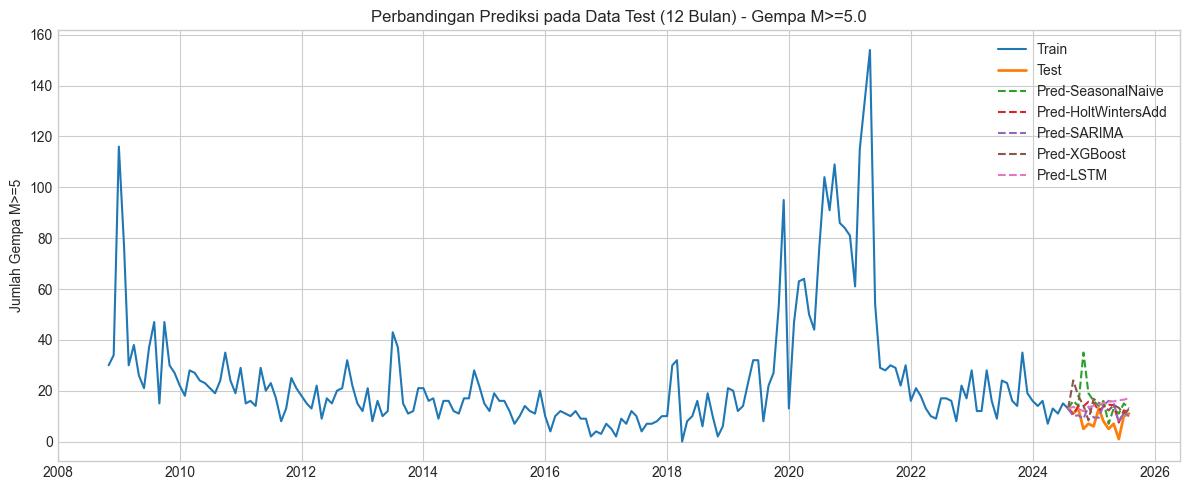

In [11]:
# Visualisasi prediksi test
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, label='Train')

# Jembatani garis train -> test supaya visual nyambung
test_bridge_idx = pd.DatetimeIndex([train.index[-1], *test.index])
test_bridge_val = np.concatenate([[train.iloc[-1]], test.values])
plt.plot(test_bridge_idx, test_bridge_val, label='Test', linewidth=2)

for name, pred in predictions.items():
    pred_bridge_idx = pd.DatetimeIndex([train.index[-1], *pred.index])
    pred_bridge_val = np.concatenate([[train.iloc[-1]], pred.values])
    plt.plot(pred_bridge_idx, pred_bridge_val, label=f'Pred-{name}', linestyle='--')

plt.title(f'Perbandingan Prediksi pada Data Test (12 Bulan) - Gempa M>={MAG_THRESHOLD}')
plt.ylabel('Jumlah Gempa M>=5')
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'comparison_test_plot.png', dpi=160, bbox_inches='tight')
plt.show()

,month,forecast
0,2025-09-01,8.522446
1,2025-10-01,9.255020
2,2025-11-01,11.496528
3,2025-12-01,13.204405
4,2026-01-01,7.526413
5,2026-02-01,6.193561
6,2026-03-01,10.901849
7,2026-04-01,11.646804
8,2026-05-01,12.055435
9,2026-06-01,5.042823


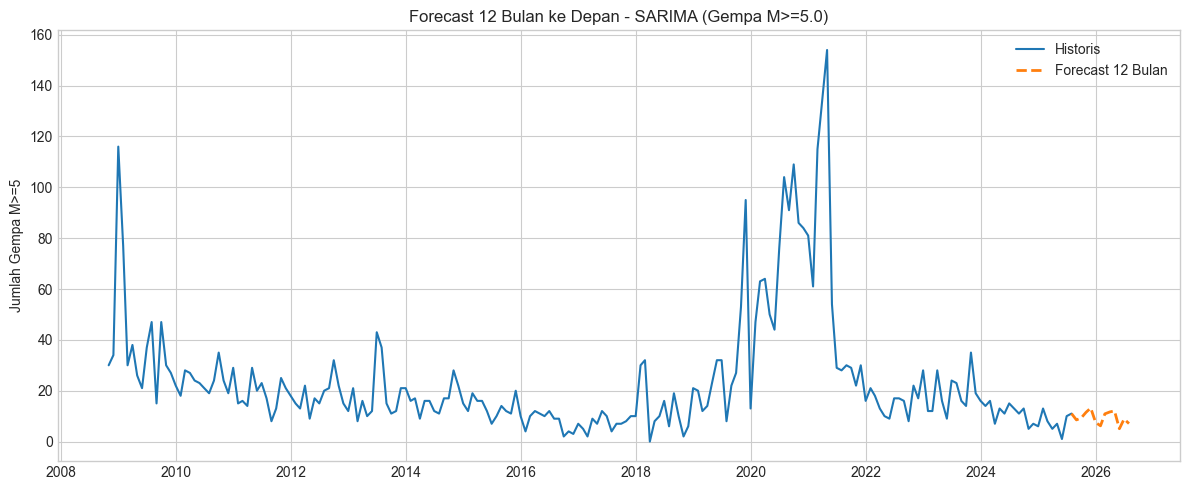

In [9]:
# Retrain model terbaik dengan seluruh data, lalu forecast 12 bulan ke depan
full = ts.copy()
future_idx = pd.date_range(full.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')

if best_model_name == 'SeasonalNaive':
    vals = full.iloc[-SEASONAL_PERIOD:].values
    future_fc = np.resize(vals, 12)

elif best_model_name == 'HoltWintersAdd':
    fit_best = ExponentialSmoothing(
        full, trend='add', seasonal='add', seasonal_periods=SEASONAL_PERIOD
    ).fit(optimized=True)
    future_fc = fit_best.forecast(12).values

elif best_model_name == 'SARIMA':
    fit_best = SARIMAX(
        full,
        order=best_order,
        seasonal_order=best_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    future_fc = fit_best.forecast(12).values

elif best_model_name == 'XGBoost':
    if not XGB_AVAILABLE:
        raise RuntimeError('XGBoost tidak tersedia pada environment ini.')
    X_full_xgb, y_full_xgb = make_supervised(full.values, N_LAGS)
    fit_best = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42
    )
    fit_best.fit(X_full_xgb, y_full_xgb)
    future_fc = recursive_forecast_sklearn(fit_best, full.values, 12, N_LAGS)

elif best_model_name == 'LSTM':
    if not TF_AVAILABLE:
        raise RuntimeError('TensorFlow tidak tersedia pada environment ini.')
    scaler_full = MinMaxScaler()
    full_scaled = scaler_full.fit_transform(full.values.reshape(-1, 1)).ravel()
    X_full_lstm, y_full_lstm = make_supervised(full_scaled, N_LAGS)
    X_full_lstm = X_full_lstm.reshape(X_full_lstm.shape[0], X_full_lstm.shape[1], 1)

    fit_best = Sequential([
        LSTM(32, input_shape=(N_LAGS, 1)),
        Dense(1)
    ])
    fit_best.compile(optimizer='adam', loss='mse')
    es = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    fit_best.fit(
        X_full_lstm,
        y_full_lstm,
        epochs=120,
        batch_size=8,
        verbose=0,
        callbacks=[es]
    )

    future_scaled = recursive_forecast_lstm(fit_best, full_scaled, 12, N_LAGS)
    future_fc = scaler_full.inverse_transform(future_scaled.reshape(-1, 1)).ravel()

else:
    raise ValueError('Nama model tidak dikenali.')

future_fc = post_process_forecast(future_fc)
forecast_12m = pd.DataFrame({
    'month': future_idx,
    'forecast': future_fc
})

display(forecast_12m)

plt.figure(figsize=(12, 5))
plt.plot(full.index, full.values, label='Historis')

# Jembatani garis historis -> forecast supaya visual nyambung
forecast_bridge_idx = pd.DatetimeIndex([full.index[-1], *future_idx])
forecast_bridge_val = np.concatenate([[full.iloc[-1]], future_fc])
plt.plot(forecast_bridge_idx, forecast_bridge_val, label='Forecast 12 Bulan', linestyle='--', linewidth=2)

plt.title(f'Forecast 12 Bulan ke Depan - {best_model_name} (Gempa M>={MAG_THRESHOLD})')
plt.ylabel('Jumlah Gempa M>=5')
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'forecast_plot.png', dpi=160, bbox_inches='tight')
plt.show()

In [10]:
# Simpan artefak hasil
import json

# Simpan split train/test
train_split_df = pd.DataFrame({
    'month': train.index,
    'target': train.values
})
test_split_df = pd.DataFrame({
    'month': test.index,
    'target': test.values
})

# Simpan prediksi test tiap model
pred_test_df = pd.DataFrame({
    'month': test.index,
    'actual': test.values
})
for model_name, pred in predictions.items():
    pred_test_df[f'pred_{model_name}'] = pred.values

results_df.to_csv(ARTIFACT_DIR / 'metrics_comparison.csv', index=False)
pred_test_df.to_csv(ARTIFACT_DIR / 'predictions_test.csv', index=False)
train_split_df.to_csv(ARTIFACT_DIR / 'train_split.csv', index=False)
test_split_df.to_csv(ARTIFACT_DIR / 'test_split.csv', index=False)
forecast_12m.to_csv(ARTIFACT_DIR / 'forecast_next_12_months.csv', index=False)

meta = {
    'data_path': str(DATA_PATH),
    'target': TARGET_COL,
    'mag_threshold': MAG_THRESHOLD,
    'test_horizon': TEST_HORIZON,
    'seasonal_period': SEASONAL_PERIOD,
    'n_lags': N_LAGS,
    'total_months': int(len(ts)),
    'train_months': int(len(train)),
    'test_months': int(len(test)),
    'xgboost_available': XGB_AVAILABLE,
    'tensorflow_available': TF_AVAILABLE,
    'best_model': best_model_name,
    'saved_models': saved_model_files if 'saved_model_files' in globals() else [],
    'metrics': results_df.to_dict(orient='records')
}

with open(ARTIFACT_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print('Artefak tersimpan di:', ARTIFACT_DIR.resolve())
print('\nSaved files:')
for p in sorted(ARTIFACT_DIR.glob('*')):
    print('-', p.name)

Artefak tersimpan di: D:\Projects\bencana_dicoding_app\timeseries_triwulan\artifacts\model_monthly_auto_select_m5

Saved files:
- comparison_test_plot.png
- forecast_next_12_months.csv
- forecast_plot.png
- metadata.json
- metrics_comparison.csv
- predictions_test.csv
- saved_models
- test_split.csv
- train_split.csv
